In [4]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalar los datos (muy importante para MLP)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [5]:
# Configuraciones
activaciones = ['relu', 'tanh', 'logistic']
capas = [(50,), (100, 50), (100, 100, 50)]

resultados = []

for act in activaciones:
    for capa in capas:
        model = MLPRegressor(hidden_layer_sizes=capa,
                             activation=act,
                             max_iter=1000,
                             random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        resultados.append({
            'activacion': act,
            'capas': capa,
            'R2': r2,
            'MAE': mae,
            'RMSE': rmse
        })

# Mostrar resultados
pd.DataFrame(resultados)


,activacion,capas,R2,MAE,RMSE
0,relu,"(50,)",0.772217,0.375931,0.546785
1,relu,"(100, 50)",0.797016,0.347207,0.516164
2,relu,"(100, 100, 50)",0.778637,0.353284,0.539024
3,tanh,"(50,)",0.768241,0.383563,0.551536
4,tanh,"(100, 50)",0.799783,0.359718,0.512633
5,tanh,"(100, 100, 50)",0.740083,0.396714,0.584081
6,logistic,"(50,)",0.770490,0.384420,0.548855
7,logistic,"(100, 50)",0.788311,0.364367,0.527115
8,logistic,"(100, 100, 50)",0.755802,0.418362,0.566145


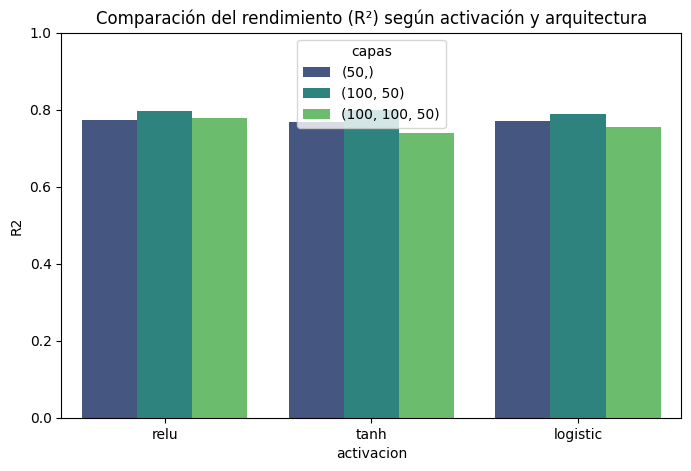

In [6]:
df_resultados = pd.DataFrame(resultados)

plt.figure(figsize=(8,5))
sns.barplot(data=df_resultados, x='activacion', y='R2', hue='capas', palette='viridis')
plt.title("Comparación del rendimiento (R²) según activación y arquitectura")
plt.ylim(0, 1)
plt.show()


In [7]:
mejor_modelo = MLPRegressor(hidden_layer_sizes=(100, 50),
                            activation='tanh',
                            max_iter=1000,
                            random_state=42)
mejor_modelo.fit(X_train, y_train)

# Predicciones
y_pred = mejor_modelo.predict(X_test)

# Métricas finales
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


R²: 0.800
MAE: 0.360
RMSE: 0.513


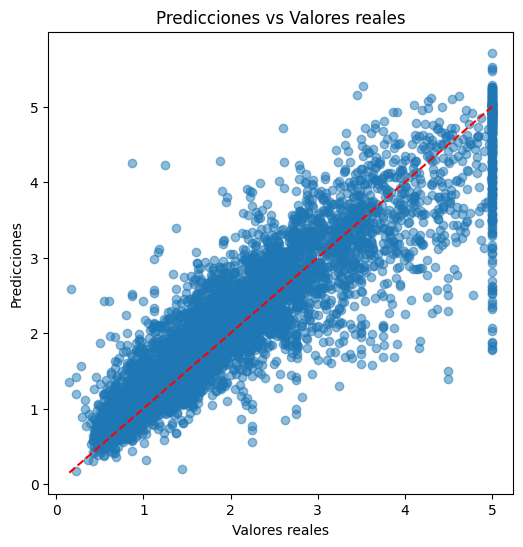

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores reales")
plt.show()


In [9]:
# Entrenamiento sin normalizar
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.3, random_state=42)

model_no_scaling = MLPRegressor(hidden_layer_sizes=(100,50),
                                activation='tanh',
                                max_iter=1000,
                                random_state=42)
model_no_scaling.fit(X_train_raw, y_train_raw)
y_pred_raw = model_no_scaling.predict(X_test_raw)

print("Sin normalización:")
print(f"R²: {r2_score(y_test_raw, y_pred_raw):.3f}")
print(f"MAE: {mean_absolute_error(y_test_raw, y_pred_raw):.3f}")


Sin normalización:
R²: 0.587
MAE: 0.539
